# 06 — Hierarchical Bayesian association: DRVI factors × CPS

Bayesian alternative to `05_mixed_models.ipynb`, using PyMC.

**What is different from `05`:**

| | `05_mixed_models` | This notebook |
|---|---|---|
| Region slopes | Binary: shared *or* fully independent per region | Partial pooling: slopes shrunk toward a common mean |
| Inference | ML/REML → p-values, asymptotic CIs | Full posterior → credible intervals, posterior probabilities |
| Region heterogeneity | χ²(9) LRT: reject or not | `σ_region`: continuous posterior over degree of heterogeneity |
| Boundary problem | `ICC = 0` collapse when donor variance hits zero | HalfNormal prior prevents the boundary |

**Requires PyMC** — run `mamba env update -p /scratch/.dotfiles/envs/conda/sst-drvi -f environment/conda.yaml` first.

**Runtime** — the vectorized ADVI scan takes ~5–15 minutes per CPS phenotype on CPU.
Individual NUTS fits (section 5) take ~2–5 minutes each.

**Data** — loads from `03_pseudobulk.ipynb` output. Run that notebook first.

## 1 — Setup

In [1]:
from __future__ import annotations

import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import scanpy as sc
import seaborn as sns
from scipy import stats

import sst_drvi as S

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="pymc")
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(4, 4))
pd.set_option("display.max_rows", 140)

### Data

Loaded from `03_pseudobulk.ipynb` output.

In [2]:
PSEUDO_DIR = S.SCRATCH / "pseudobulk"

activity = pd.read_parquet(PSEUDO_DIR / "activity.parquet")
meta = pd.read_parquet(PSEUDO_DIR / "meta.parquet")

print(f"{activity.shape[0]} donor × region units x {activity.shape[1]} live directions")
print(f"CPS columns: {[c for c in meta.columns if c.startswith('CPS')]}")

516 donor × region units x 124 live directions
CPS columns: ['CPS_Local', 'CPS_Local_ABeta', 'CPS_Local_pTau', 'CPS_Global', 'CPS_Global_ABeta', 'CPS_Global_pTau']


In [3]:
# Covariates sit in meta alongside CPS scores.  Sex → binary, age and PMI → z-scored.
# The MultiIndex has levels (Donor ID, Brain Region).

donors  = meta.index.get_level_values("Donor ID").unique().tolist()
regions = meta.index.get_level_values("Brain Region").unique().tolist()
donor_map  = {d: i for i, d in enumerate(donors)}
region_map = {r: i for i, r in enumerate(regions)}

donor_idx  = meta.index.get_level_values("Donor ID").map(donor_map).to_numpy().astype(int)
region_idx = meta.index.get_level_values("Brain Region").map(region_map).to_numpy().astype(int)

sex_enc = (meta["Sex"] == "Male").astype(float).values
age_raw = meta["Age at Death"].astype(float)
pmi_raw = meta["PMI"].astype(float)
age_z   = ((age_raw - age_raw.mean()) / age_raw.std()).values
pmi_z   = ((pmi_raw - pmi_raw.mean()) / pmi_raw.std()).values

n_obs     = len(meta)
n_donors  = len(donors)
n_regions = len(regions)

# Z-score each direction so slopes are on a common scale.
activity_z = (activity.values - activity.values.mean(0)) / (activity.values.std(0) + 1e-8)

LOCAL_SCORES = {
    "CPS_Local": "composite",
    "CPS_Local_ABeta": "ABeta",
    "CPS_Local_pTau": "pTau",
}

def cps_z_vec(phenotype: str) -> np.ndarray:
    vals = meta[phenotype].astype(float).values
    return (vals - np.nanmean(vals)) / np.nanstd(vals)

print(f"n_donors={n_donors}, n_regions={n_regions}, n_obs={n_obs}")
print(f"directions: {activity.shape[1]}")

n_donors=84, n_regions=10, n_obs=516
directions: 124


## 2 — Model

### Generative model

For each factor direction $j$ observed in donor × region unit $i$:

$$
y_{ij} \sim \mathcal{N}(\mu_{ij},\; \sigma_j)
$$

$$
\mu_{ij} = \underbrace{\alpha_{r(i),j}}_{\text{region intercept}}
          + \underbrace{\beta_{r(i),j}}_{\text{region slope}} \cdot \text{CPS}_i
          + \underbrace{u_{d(i),j}}_{\text{donor intercept}}
          + b_{\text{sex},j}\,\text{sex}_i
          + b_{\text{age},j}\,\text{age}_i
          + b_{\text{pmi},j}\,\text{pmi}_i
$$

**Region slopes with partial pooling** (the key difference from `05_mixed_models`):

$$
\beta_{r,j} \sim \mathcal{N}(\mu^{\beta}_j,\; \sigma^{\beta}_j)
$$

$\mu^{\beta}_j$ is the *pan-region slope* for direction $j$; $\sigma^{\beta}_j$ is the
*between-region heterogeneity*. Regions with fewer observations are shrunk more toward the
common mean — a data-adaptive regularisation rather than a binary pan/regional decision.

**Priors** — all on z-scored scales, so $\mathcal{N}(0,1)$ is weakly informative:

| Parameter | Prior | Rationale |
|---|---|---|
| $\mu^{\beta}_j$ | $\mathcal{N}(0, 1)$ | Pan slope; unit is 1 SD of direction per 1 SD of CPS |
| $\sigma^{\beta}_j$ | $\text{HalfNormal}(0.5)$ | Region slopes unlikely to span more than ±1 SD around the pan slope |
| $u_{d,j}$ | $\mathcal{N}(0, \sigma^u_j)$ | Donor intercept; $\sigma^u_j \sim \text{HalfNormal}(1)$ |
| $\sigma_j$ | $\text{HalfNormal}(1)$ | Residual; HalfNormal avoids the ICC=0 boundary collapse |

In [4]:
def build_vectorized_model(cps_z: np.ndarray, activity_z: np.ndarray):
    """One PyMC model for all directions simultaneously (vectorized over directions).

    This is 10–50× faster than fitting each direction separately because the ELBO
    gradient computation is batched across directions.  The model is identical to
    the per-direction version; only the shape of each variable changes.

    Parameters
    ----------
    cps_z : (n_obs,) z-scored CPS values for one phenotype
    activity_z : (n_obs, n_directions) z-scored direction activations
    """
    n_dir = activity_z.shape[1]

    with pm.Model() as model:
        # --- region slopes with partial pooling ---
        mu_beta    = pm.Normal("mu_beta",    0, 1,   shape=(n_dir,))
        sigma_beta = pm.HalfNormal("sigma_beta", 0.5, shape=(n_dir,))
        # Non-centred: beta_region_raw ~ N(0,1); beta_region = mu_beta + sigma_beta * raw
        beta_raw   = pm.Normal("beta_raw", 0, 1, shape=(n_dir, n_regions))
        # beta_region: (n_dir, n_regions)
        beta_region = pm.Deterministic(
            "beta_region", mu_beta[:, None] + sigma_beta[:, None] * beta_raw
        )

        # --- region fixed intercepts ---
        alpha_region = pm.Normal("alpha_region", 0, 1, shape=(n_dir, n_regions))

        # --- donor random intercepts (non-centred) ---
        sigma_u = pm.HalfNormal("sigma_u", 1, shape=(n_dir,))
        u_raw   = pm.Normal("u_raw", 0, 1, shape=(n_dir, n_donors))
        u_donor = pm.Deterministic("u_donor", sigma_u[:, None] * u_raw)

        # --- covariates ---
        b_sex = pm.Normal("b_sex", 0, 1, shape=(n_dir,))
        b_age = pm.Normal("b_age", 0, 1, shape=(n_dir,))
        b_pmi = pm.Normal("b_pmi", 0, 1, shape=(n_dir,))

        # --- expected value: (n_dir, n_obs) ---
        mu = (
            alpha_region[:, region_idx]          # region intercept
            + beta_region[:, region_idx] * cps_z # region slope × CPS
            + u_donor[:, donor_idx]              # donor intercept
            + b_sex[:, None] * sex_enc
            + b_age[:, None] * age_z
            + b_pmi[:, None] * pmi_z
        )

        sigma_res = pm.HalfNormal("sigma_res", 1, shape=(n_dir,))
        # observed: (n_obs, n_dir)
        pm.Normal("obs", mu.T, sigma_res[None, :], observed=activity_z)

    return model


def build_single_model(cps_z: np.ndarray, y_z: np.ndarray):
    """Full hierarchical model for one direction — use for NUTS on top hits."""
    with pm.Model() as model:
        mu_beta    = pm.Normal("mu_beta",    0, 1)
        sigma_beta = pm.HalfNormal("sigma_beta", 0.5)
        beta_raw   = pm.Normal("beta_raw", 0, 1, shape=(n_regions,))
        beta_region = pm.Deterministic("beta_region",
                                       mu_beta + sigma_beta * beta_raw)

        alpha_region = pm.Normal("alpha_region", 0, 1, shape=(n_regions,))

        sigma_u = pm.HalfNormal("sigma_u", 1)
        u_raw   = pm.Normal("u_raw", 0, 1, shape=(n_donors,))
        u_donor = pm.Deterministic("u_donor", sigma_u * u_raw)

        b_sex = pm.Normal("b_sex", 0, 1)
        b_age = pm.Normal("b_age", 0, 1)
        b_pmi = pm.Normal("b_pmi", 0, 1)

        mu = (alpha_region[region_idx]
              + beta_region[region_idx] * cps_z
              + u_donor[donor_idx]
              + b_sex * sex_enc
              + b_age * age_z
              + b_pmi * pmi_z)

        sigma_res = pm.HalfNormal("sigma_res", 1)
        pm.Normal("obs", mu, sigma_res, observed=y_z)

    return model

### Model graph

`pm.model_to_graphviz` renders the plate diagram directly from `build_vectorized_model`,
so it reflects the actual model object rather than a hand-drawn approximation: plates are
the `n_dir`/`n_regions`/`n_donors` dimensions, and arrows are the dependencies encoded above.

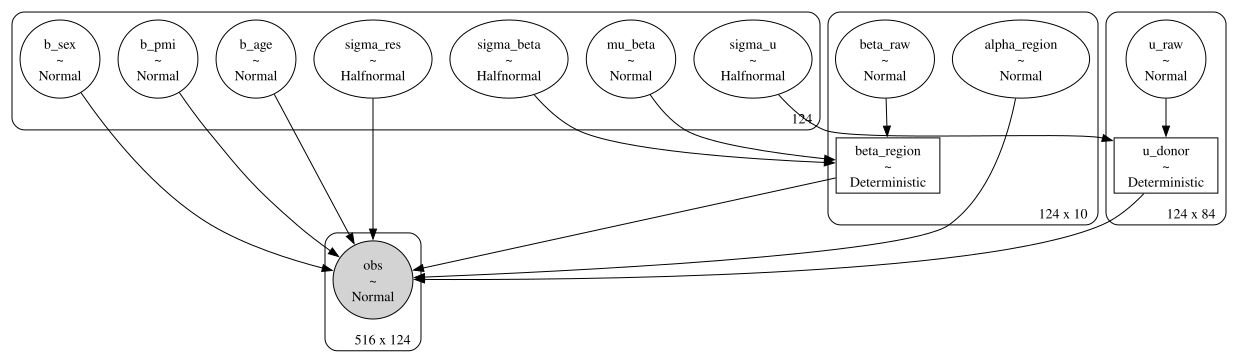

In [5]:
graph_model = build_vectorized_model(cps_z_vec("CPS_Local"), activity_z)
pm.model_to_graphviz(graph_model)

### Prior predictive check

Before fitting data, sample from the priors to verify that they are weakly informative:
a direction's z-scored activation should plausibly range from about −2 to +2 across units,
not ±20 (too wide) or ±0.1 (too narrow).

Sampling: [alpha_region, b_age, b_pmi, b_sex, beta_raw, mu_beta, obs, sigma_beta, sigma_res, sigma_u, u_raw]


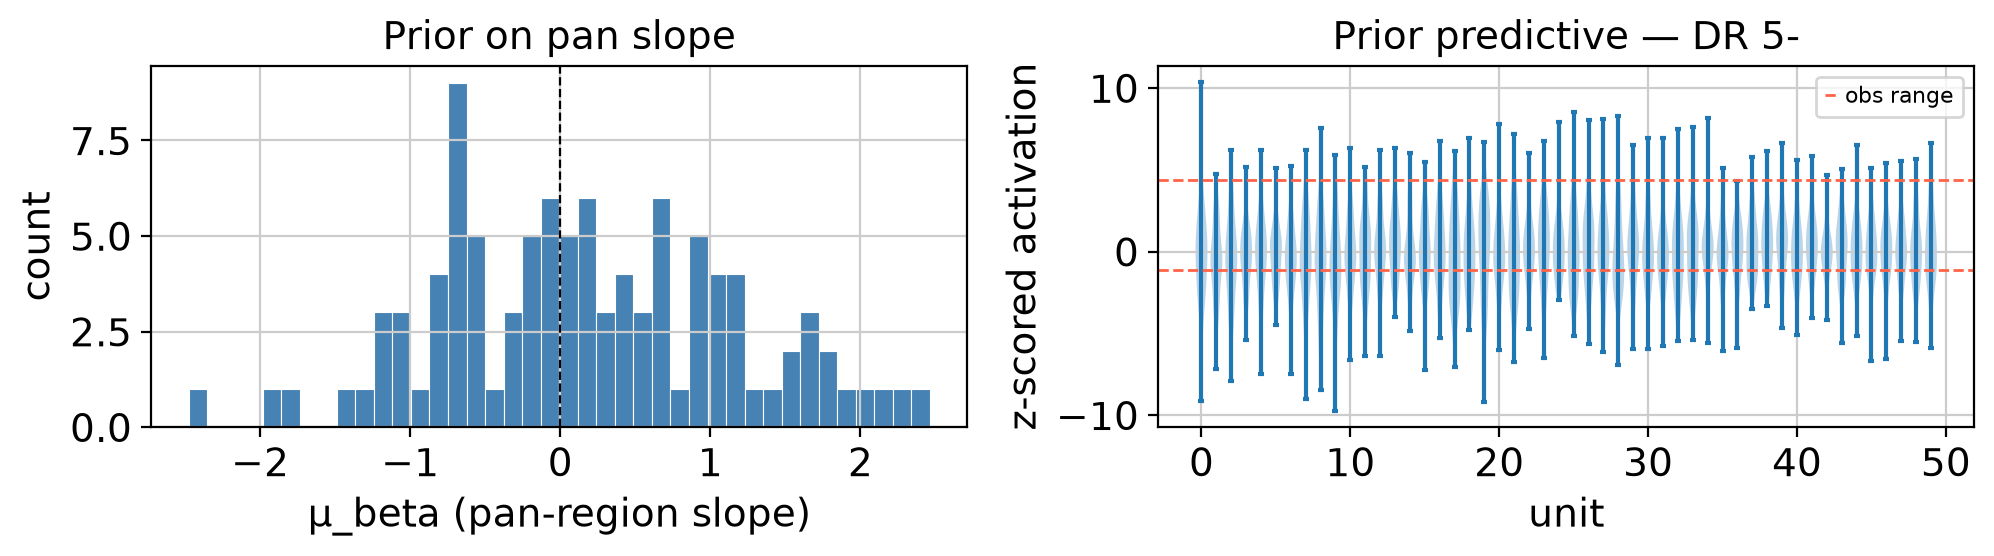

Prior μ_beta: mean=0.18, 95% HDI [-1.62, 2.13]


In [6]:
direction = activity.columns[9]   # pick one direction to inspect
y_z_one   = activity_z[:, 9]
cps_z_one = cps_z_vec("CPS_Local")

with build_single_model(cps_z_one, y_z_one):
    prior_pred = pm.sample_prior_predictive(100, random_seed=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Prior on mu_beta
mu_samples = prior_pred.prior["mu_beta"].values.flatten()
axes[0].hist(mu_samples, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].axvline(0, color="k", lw=0.8, ls="--")
axes[0].set(xlabel="μ_beta (pan-region slope)", ylabel="count", title="Prior on pan slope")

# Prior predictive for one unit vs. observed range
obs_samples = prior_pred.prior_predictive["obs"].values.reshape(-1, n_obs)[:, :50]
n_show = obs_samples.shape[1]
axes[1].violinplot([obs_samples[:, i] for i in range(n_show)], positions=range(n_show), widths=0.8)
axes[1].axhline(y_z_one.min(), color="tomato", lw=1, ls="--", label="obs range")
axes[1].axhline(y_z_one.max(), color="tomato", lw=1, ls="--")
axes[1].set(xlabel="unit", ylabel="z-scored activation", title=f"Prior predictive — {direction}")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Prior μ_beta: mean={mu_samples.mean():.2f}, 95% HDI [{np.percentile(mu_samples,2.5):.2f}, "
      f"{np.percentile(mu_samples,97.5):.2f}]")

## 3 — Fit

ADVI fits the variational distribution over all directions at once (one model per phenotype,
all directions stacked as the batch dimension).  This is 10–50× faster than 128 sequential
NUTS calls while still giving posterior means and approximate credible intervals.

Results are cached to `PSEUDO_DIR / "bayes_vi_{phenotype}.parquet"` so the scan can be
re-loaded without re-running.

In [7]:
def extract_vi_summary(trace, direction_names, region_names):
    """Pull mu_beta, sigma_beta, sigma_u posteriors and compute P(mu_beta > 0)."""
    post = trace.posterior
    mu_beta    = post["mu_beta"].values.reshape(-1, len(direction_names))
    sigma_beta = post["sigma_beta"].values.reshape(-1, len(direction_names))
    sigma_u    = post["sigma_u"].values.reshape(-1, len(direction_names))
    beta_region = post["beta_region"].values.reshape(-1, len(direction_names), len(region_names))

    rows = []
    for j, name in enumerate(direction_names):
        mb = mu_beta[:, j]
        sb = sigma_beta[:, j]
        su = sigma_u[:, j]
        row = {
            "direction":      name,
            "mu_beta_mean":   float(mb.mean()),
            "mu_beta_low":    float(np.percentile(mb, 2.5)),
            "mu_beta_high":   float(np.percentile(mb, 97.5)),
            "sigma_beta_mean": float(sb.mean()),
            "sigma_u_mean":   float(su.mean()),
            "p_positive":     float((mb > 0).mean()),
        }
        for r, rname in enumerate(region_names):
            br = beta_region[:, j, r]
            row[f"beta_{rname}_mean"] = float(br.mean())
            row[f"beta_{rname}_low"]  = float(np.percentile(br, 2.5))
            row[f"beta_{rname}_high"] = float(np.percentile(br, 97.5))
        rows.append(row)
    return pd.DataFrame(rows).set_index("direction")


RERUN_VI = False   # set True to re-fit even if cache exists

vi_results = {}

for phenotype, label in LOCAL_SCORES.items():
    cache_path = PSEUDO_DIR / f"bayes_vi_{phenotype}.parquet"

    if cache_path.exists() and not RERUN_VI:
        vi_results[label] = pd.read_parquet(cache_path)
        print(f"{label}: loaded from cache ({len(vi_results[label])} directions)")
        continue

    print(f"\n=== {phenotype} ({label}) — ADVI scan ===")
    cps_z = cps_z_vec(phenotype)
    model = build_vectorized_model(cps_z, activity_z)

    with model:
        advi = pm.ADVI()
        approx = advi.fit(
            20_000,
            callbacks=[pm.variational.callbacks.CheckParametersConvergence(
                tolerance=1e-4, diff="absolute")],
        )
        trace = approx.sample(2_000, random_seed=42)

    df = extract_vi_summary(trace, activity.columns.tolist(), regions)
    df.to_parquet(cache_path)
    np.save(str(cache_path).replace('.parquet', '_elbo.npy'), approx.hist)
    vi_results[label] = df
    n_pos  = (df["p_positive"] > 0.95).sum()
    n_neg  = (df["p_positive"] < 0.05).sum()
    n_het  = (df["sigma_beta_mean"] > 0.2).sum()
    print(f"  P(slope>0) > 0.95: {n_pos}  |  P(slope<0) > 0.95: {n_neg}  |  "
          f"sigma_beta > 0.2: {n_het}")


=== CPS_Local (composite) — ADVI scan ===


Output()

Finished [100%]: Average Loss = 78,372


  P(slope>0) > 0.95: 35  |  P(slope<0) > 0.95: 35  |  sigma_beta > 0.2: 0

=== CPS_Local_ABeta (ABeta) — ADVI scan ===


Output()

Finished [100%]: Average Loss = 78,471


  P(slope>0) > 0.95: 33  |  P(slope<0) > 0.95: 30  |  sigma_beta > 0.2: 0

=== CPS_Local_pTau (pTau) — ADVI scan ===


Output()

Finished [100%]: Average Loss = 78,379


  P(slope>0) > 0.95: 35  |  P(slope<0) > 0.95: 39  |  sigma_beta > 0.2: 0


### 3b — ADVI convergence

ELBO history saved alongside the parquet cache. "Not available" means
the VI results were loaded from cache — set `RERUN_VI = True` to regenerate.
A well-converged fit shows a rapid initial drop then a long flat tail;
the final 100 iterations should look stationary.

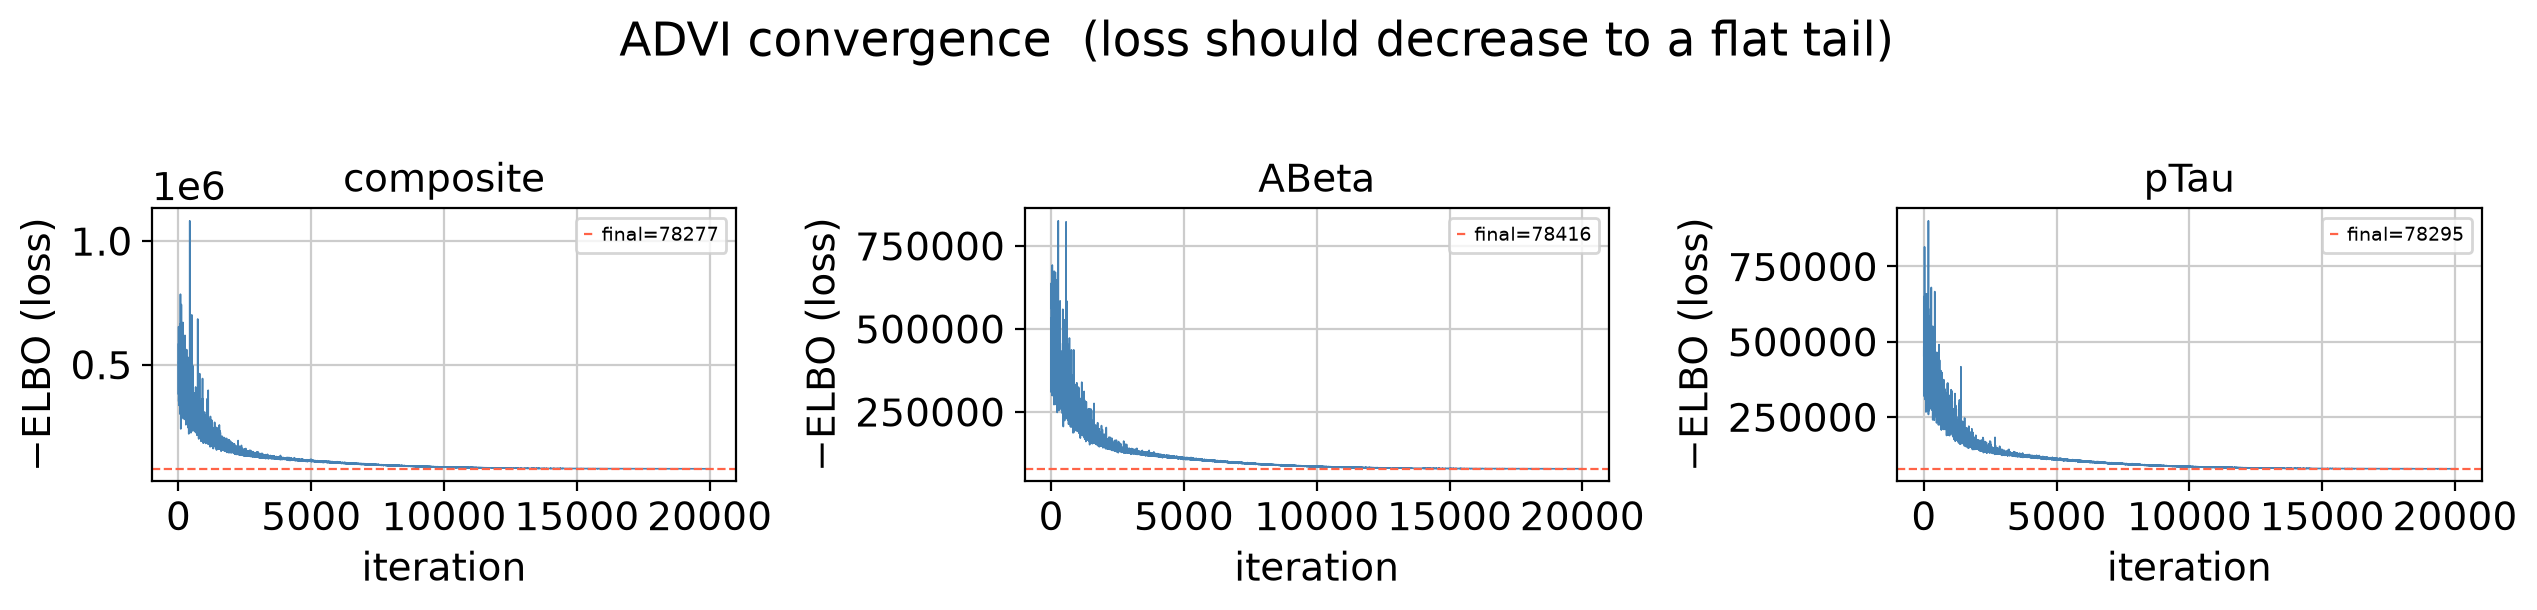

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, (phenotype, label) in zip(axes, LOCAL_SCORES.items()):
    elbo_path = PSEUDO_DIR / f"bayes_vi_{phenotype}_elbo.npy"
    if elbo_path.exists():
        hist = np.load(str(elbo_path))
        ax.plot(hist, lw=0.6, color="steelblue")
        ax.axhline(hist[-100:].mean(), color="tomato", ls="--", lw=0.8,
                   label=f"final={hist[-1]:.0f}")
        ax.set(xlabel="iteration", ylabel="−ELBO (loss)", title=label)
        ax.legend(fontsize=7)
    else:
        ax.text(0.5, 0.5, "not available\n(loaded from cache)",
                ha="center", va="center", transform=ax.transAxes, fontsize=10)
        ax.set(title=label)
plt.suptitle("ADVI convergence  (loss should decrease to a flat tail)", y=1.02)
plt.tight_layout()
plt.show()

## 4 — Results

In [9]:
# Sort by |mu_beta_mean|; show the 20 strongest pan-region associations for CPS_Local.
composite = vi_results["composite"].copy()
composite["abs_mu"] = composite["mu_beta_mean"].abs()
composite["strong_positive"] = composite["p_positive"] > 0.95
composite["strong_negative"] = composite["p_positive"] < 0.05

top = composite.sort_values("abs_mu", ascending=False).head(20)
print(f"Directions with P(slope>0) > 0.95:  {composite['strong_positive'].sum()}")
print(f"Directions with P(slope<0) > 0.95:  {composite['strong_negative'].sum()}")
print(f"\nTop 20 by |pan slope|:")
top[["mu_beta_mean", "mu_beta_low", "mu_beta_high",
     "sigma_beta_mean", "sigma_u_mean", "p_positive"]].round(3)

Directions with P(slope>0) > 0.95:  35
Directions with P(slope<0) > 0.95:  35

Top 20 by |pan slope|:


,mu_beta_mean,mu_beta_low,mu_beta_high,sigma_beta_mean,sigma_u_mean,p_positive
direction,,,,,,
DR 15+,-0.246,-0.320,-0.169,0.072,0.362,0.0
DR 36+,0.245,0.164,0.333,0.056,0.355,1.0
DR 53-,0.241,0.156,0.323,0.082,0.237,1.0
DR 16+,-0.237,-0.313,-0.160,0.089,0.327,0.0
DR 4+,-0.220,-0.296,-0.148,0.086,0.406,0.0
DR 17-,0.218,0.133,0.299,0.048,0.390,1.0
DR 35-,-0.216,-0.296,-0.139,0.069,0.418,0.0
DR 21+,-0.215,-0.296,-0.134,0.078,0.324,0.0
DR 47+,0.211,0.128,0.296,0.059,0.377,1.0


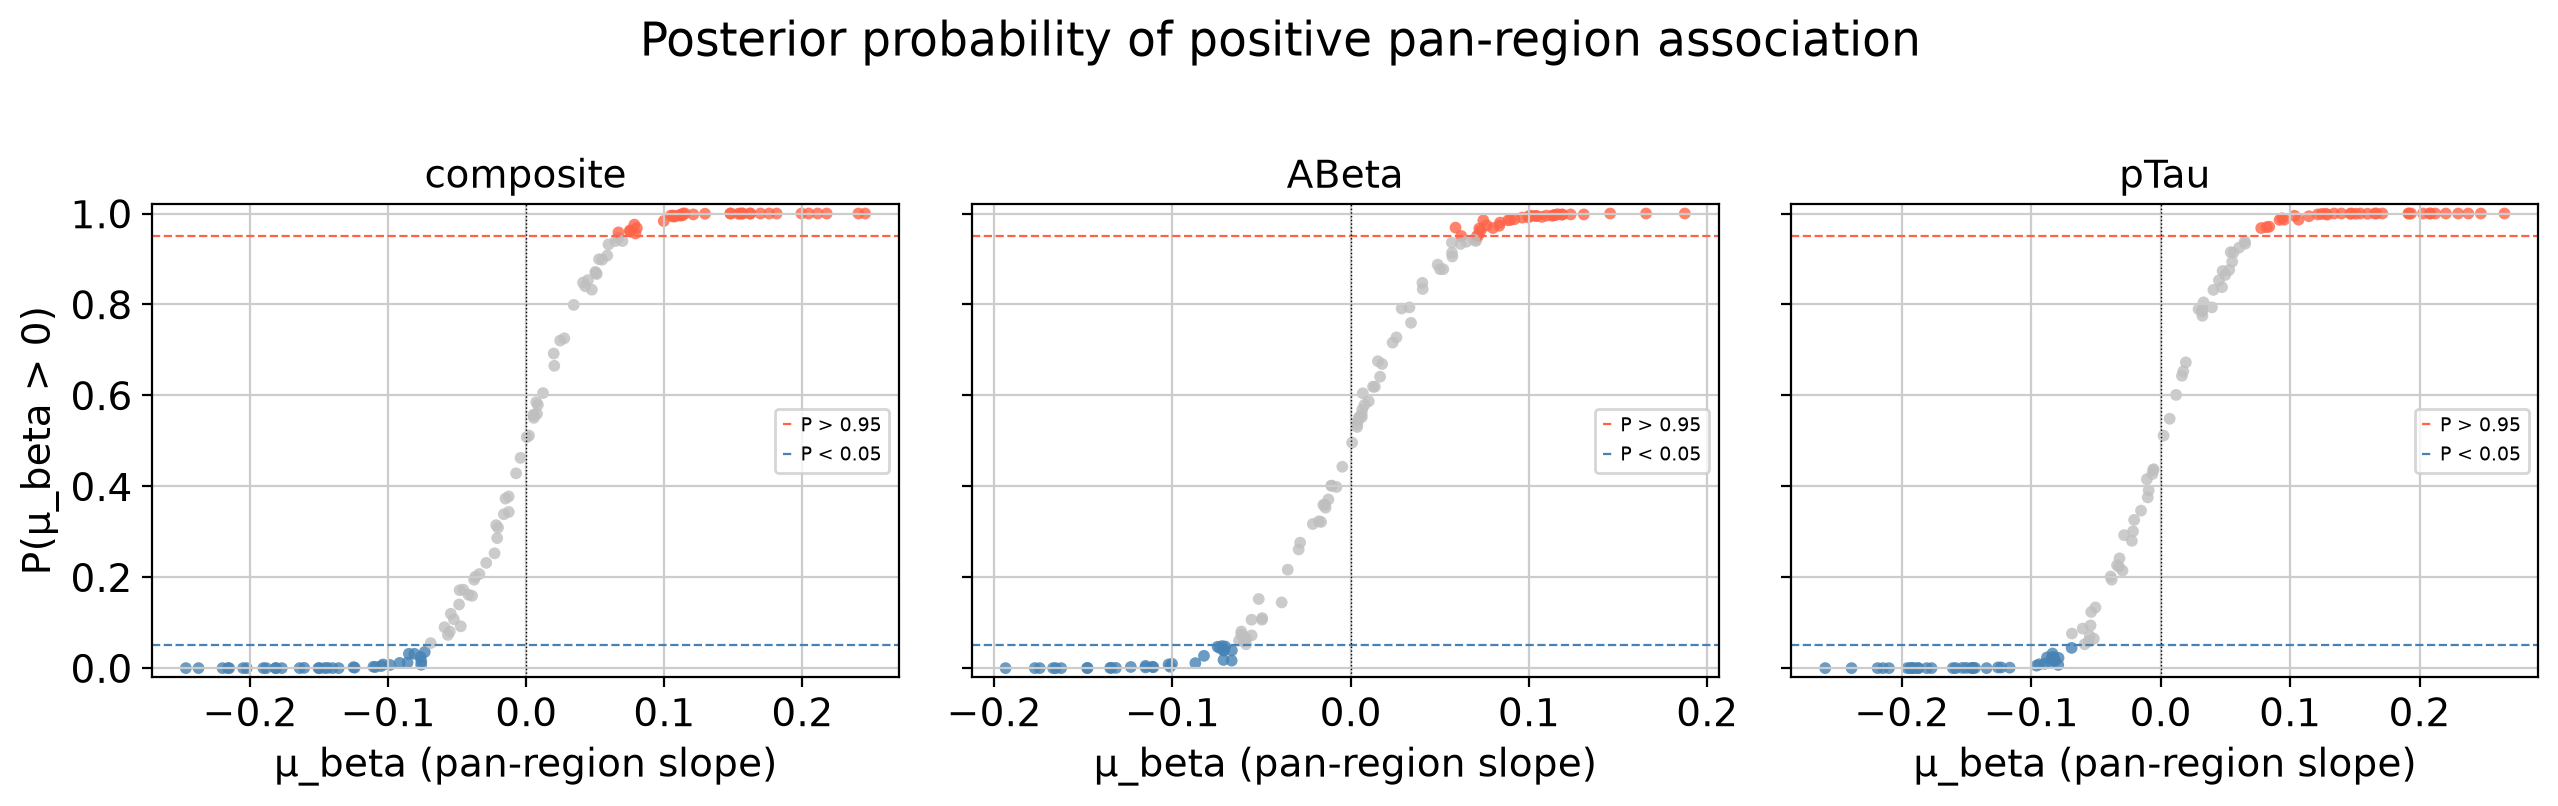

In [10]:
# Posterior probability plot: P(mu_beta > 0) vs. mu_beta_mean.
# This is the Bayesian analogue of the frequentist volcano (q vs. effect size).
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, (label, df) in zip(axes, vi_results.items()):
    p_pos = df["p_positive"].values
    mb    = df["mu_beta_mean"].values

    # Colour by direction of association
    color = np.where(p_pos > 0.95, "tomato",
            np.where(p_pos < 0.05, "steelblue", "0.75"))
    ax.scatter(mb, p_pos, c=color, s=18, linewidths=0, alpha=0.8)
    ax.axhline(0.95, color="tomato",    ls="--", lw=0.8, label="P > 0.95")
    ax.axhline(0.05, color="steelblue", ls="--", lw=0.8, label="P < 0.05")
    ax.axvline(0, color="k", lw=0.5, ls=":")
    ax.set(xlabel="μ_beta (pan-region slope)", title=label,
           ylim=(-0.02, 1.02))
    ax.legend(fontsize=7)

axes[0].set_ylabel("P(μ_beta > 0)")
plt.suptitle("Posterior probability of positive pan-region association", y=1.01)
plt.tight_layout()
plt.show()

## 5 — Regional patterns

Partial pooling gives `σ_beta` — the between-region SD of the slopes. Unlike the
binary LRT in `05_mixed_models`, this is a continuous posterior over the degree of
heterogeneity: small means the pan slope is a good summary; large means regions diverge.

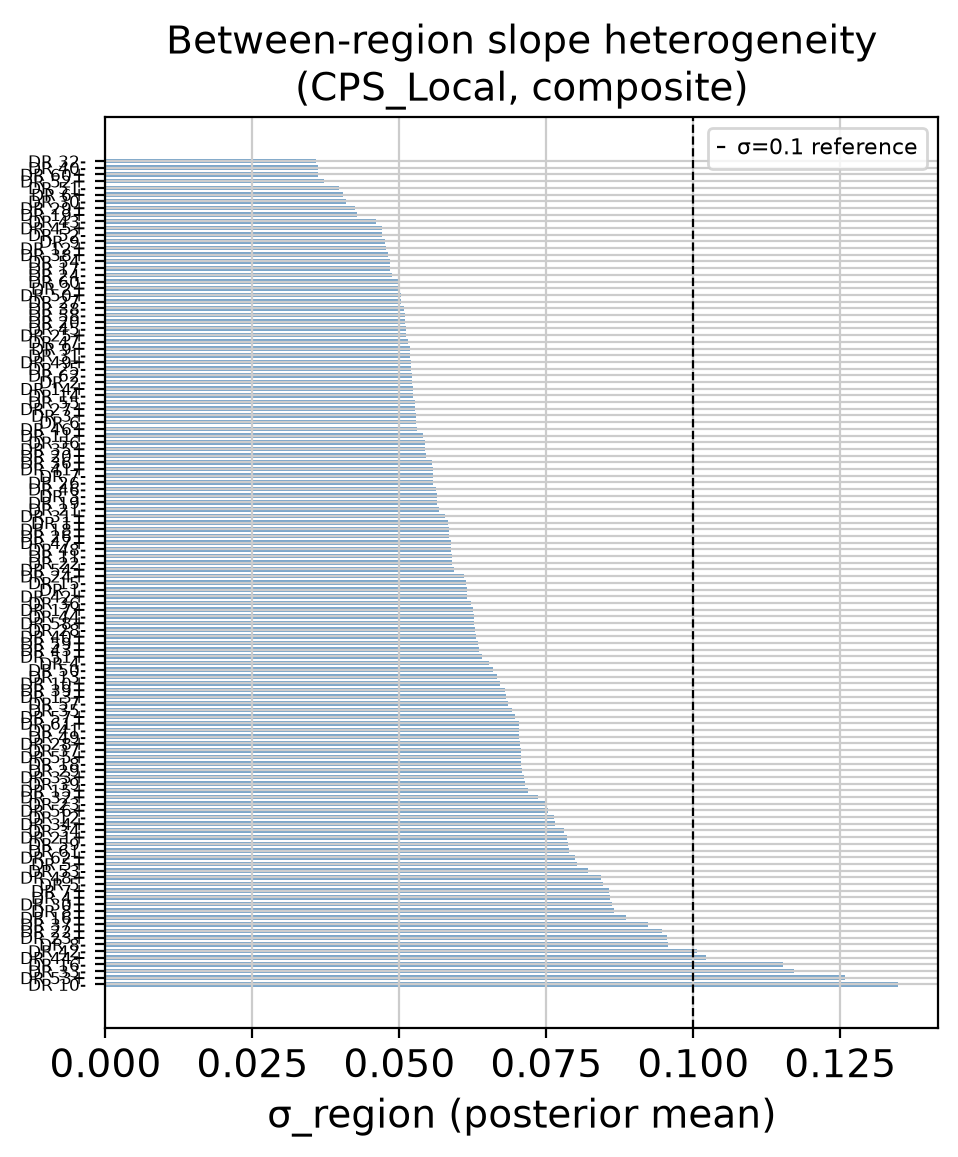

Top 10 by region heterogeneity:


,sigma_beta_mean,mu_beta_mean,p_positive
direction,,,
DR 10-,0.135,0.121,0.998
DR 53+,0.126,-0.177,0.000
DR 33-,0.117,0.008,0.579
DR 16-,0.115,0.025,0.720
DR 44+,0.102,-0.205,0.000
DR 42-,0.101,0.075,0.963
DR 8-,0.096,0.008,0.560
DR 23+,0.096,-0.046,0.172
DR 22+,0.095,-0.181,0.000


In [11]:
# Partial pooling gives sigma_beta — the between-region SD of the slopes.
# Small sigma_beta means the pan slope is a good summary; large means regions diverge.
# Compare this to the LRT p-value from 05_mixed_models (if results were saved there).

# sigma_beta posterior for CPS_Local, sorted by mean.
df = vi_results["composite"].sort_values("sigma_beta_mean", ascending=False)

fig, ax = plt.subplots(figsize=(5, 6))
y = np.arange(len(df))
ax.barh(y, df["sigma_beta_mean"], color="steelblue", alpha=0.7, height=0.7)
ax.set(yticks=y, yticklabels=df.index, xlabel="σ_region (posterior mean)",
       title="Between-region slope heterogeneity\n(CPS_Local, composite)")
ax.tick_params(axis="y", labelsize=6)
ax.axvline(0.1, color="k", ls="--", lw=0.8, label="σ=0.1 reference")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Top 10 by region heterogeneity:")
df[["sigma_beta_mean", "mu_beta_mean", "p_positive"]].head(10).round(3)

## 6 — Top hits

NUTS gives the exact posterior where ADVI gives an approximation.  Run it on the
5 directions with the highest P(mu_beta > 0) for CPS_Local.  Each fit takes
~2–5 minutes with 1 000 draws and 1 000 tune steps.

Results are cached to `PSEUDO_DIR / "bayes_nuts_{direction}.nc"` as NetCDF via ArviZ.

In [12]:
RERUN_NUTS = False
TOP_N      = 5

top_directions = (
    vi_results["composite"]
    .assign(score=lambda d: np.maximum(d["p_positive"], 1 - d["p_positive"]))
    .sort_values("score", ascending=False)
    .head(TOP_N)
    .index.tolist()
)
print("NUTS targets:", top_directions)

nuts_traces = {}
cps_z_local = cps_z_vec("CPS_Local")

for direction in top_directions:
    cache = PSEUDO_DIR / f"bayes_nuts_{direction.replace(' ', '_')}.nc"
    if cache.exists() and not RERUN_NUTS:
        nuts_traces[direction] = az.from_netcdf(str(cache))
        print(f"{direction}: loaded from cache")
        continue

    print(f"\nFitting NUTS: {direction}")
    j = list(activity.columns).index(direction)
    y_z_j = activity_z[:, j]

    model = build_single_model(cps_z_local, y_z_j)
    with model:
        trace = pm.sample(
            1_000, tune=1_000, target_accept=0.9,
            random_seed=42, progressbar=True,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": False},
        )
    trace.to_netcdf(str(cache))
    nuts_traces[direction] = trace
    print(az.summary(trace, var_names=["mu_beta", "sigma_beta", "sigma_u"]).round(3).to_string())

NUTS targets: ['DR 4+', 'DR 4-', 'DR 3+', 'DR 10+', 'DR 14+']


DR 4+: loaded from cache


DR 4-: loaded from cache


DR 3+: loaded from cache


DR 10+: loaded from cache


DR 14+: loaded from cache


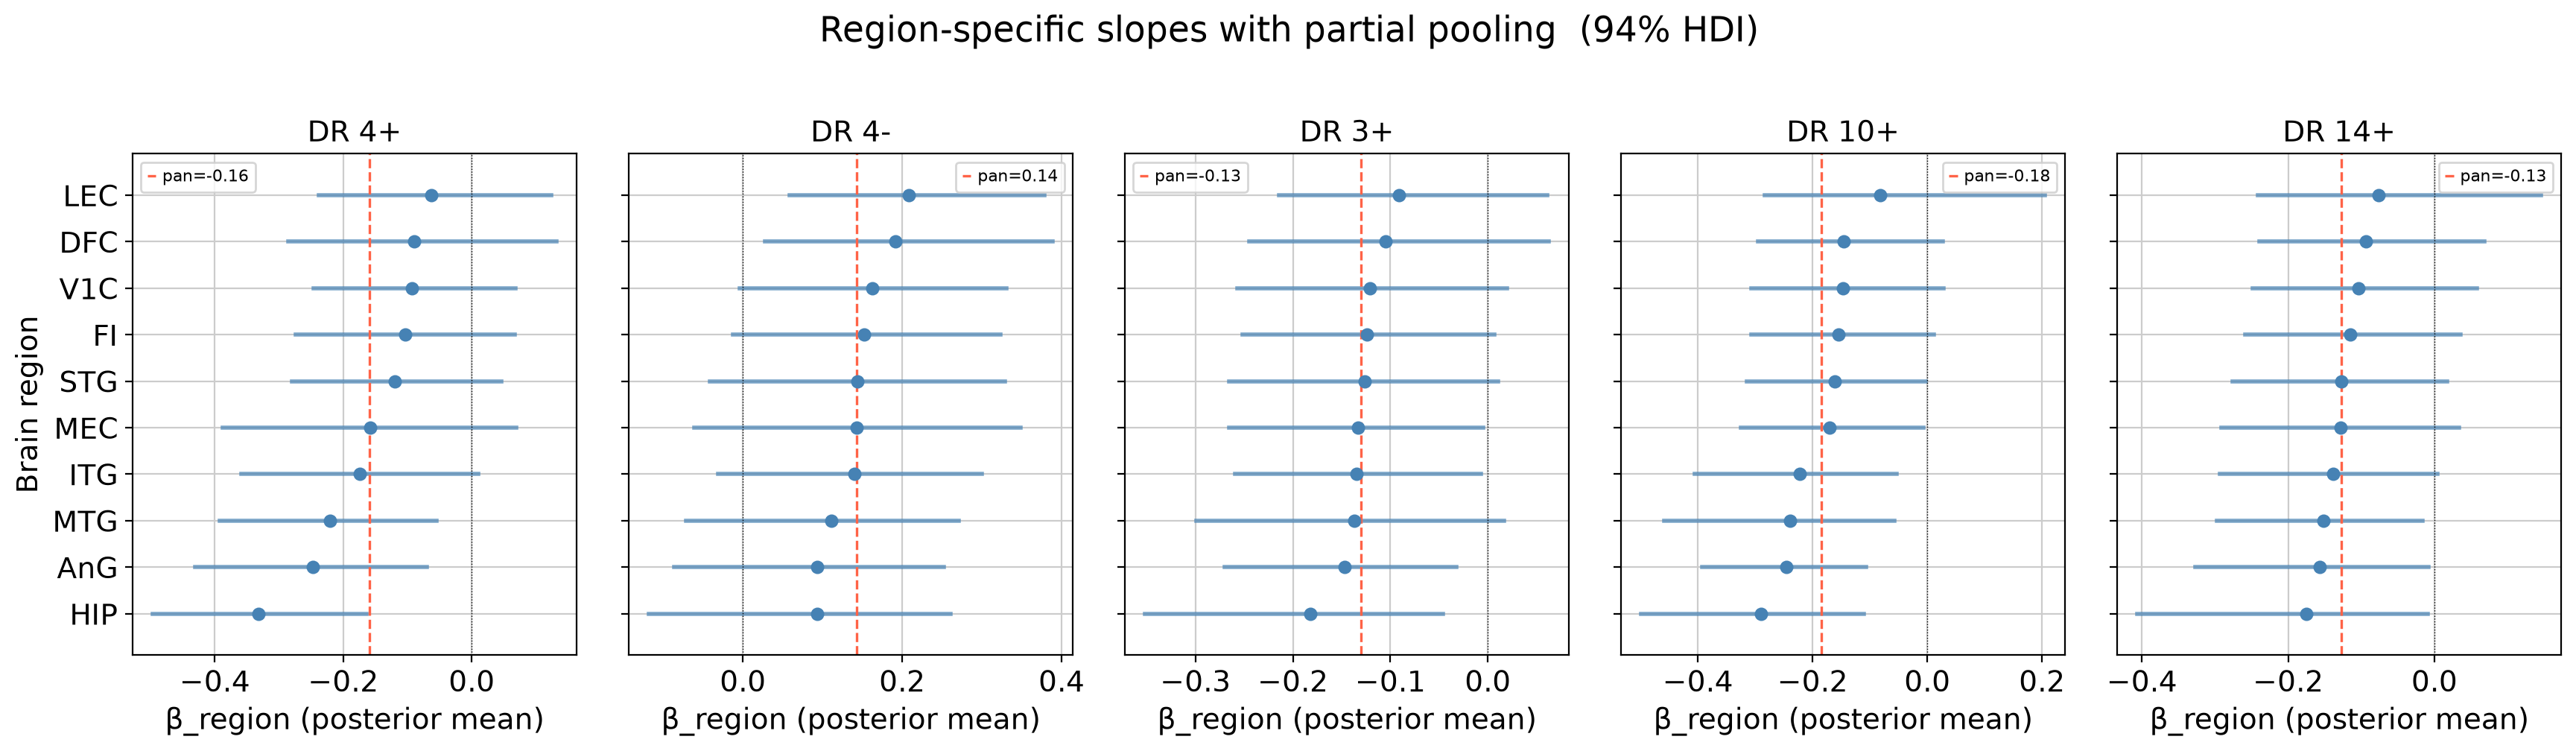

In [13]:
# Forest plot: region-specific slopes (beta_region) with partial pooling visible.
# Each panel is one top direction; dots are posterior means, bars are 94% HDIs.
# The pan-region slope (mu_beta) is shown as a vertical dashed line.
# Partial pooling pulls outlier regions toward the common mean.

n_top = len(nuts_traces)
fig, axes = plt.subplots(1, n_top, figsize=(3.5 * n_top, 5), sharey=True)
if n_top == 1:
    axes = [axes]

for ax, (direction, trace) in zip(axes, nuts_traces.items()):
    post = trace.posterior
    mu_beta_post    = post["mu_beta"].values.flatten()
    beta_region_post = post["beta_region"].values.reshape(-1, n_regions)

    means = beta_region_post.mean(0)
    low   = np.percentile(beta_region_post, 3, axis=0)
    high  = np.percentile(beta_region_post, 97, axis=0)
    order = np.argsort(means)

    y = np.arange(n_regions)
    ax.barh(y, means[order], left=0, color="steelblue", alpha=0.0)
    for i, idx in enumerate(order):
        ax.plot([low[idx], high[idx]], [i, i], color="steelblue", lw=2, alpha=0.7)
        ax.scatter(means[idx], i, color="steelblue", s=30, zorder=3)
    ax.axvline(mu_beta_post.mean(), color="tomato", ls="--", lw=1.2,
               label=f"pan={mu_beta_post.mean():.2f}")
    ax.axvline(0, color="k", lw=0.5, ls=":")
    ax.set(yticks=y, yticklabels=[regions[i] for i in order],
           xlabel="β_region (posterior mean)", title=direction)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Brain region")
plt.suptitle("Region-specific slopes with partial pooling  (94% HDI)", y=1.01)
plt.tight_layout()
plt.show()

Sampling: [obs]


Output()

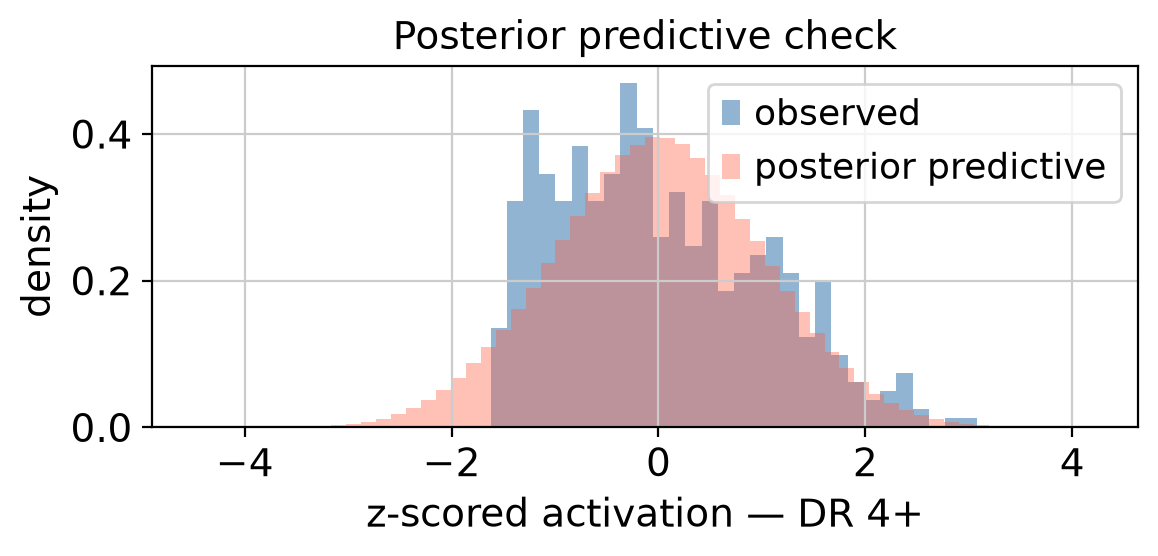

In [14]:
# Posterior predictive check for the strongest hit.
top_dir = top_directions[0]
top_trace = nuts_traces[top_dir]
j = list(activity.columns).index(top_dir)
y_z_j = activity_z[:, j]

with build_single_model(cps_z_local, y_z_j):
    ppc = pm.sample_posterior_predictive(top_trace, random_seed=42)

obs_pred = ppc.posterior_predictive["obs"].values.reshape(-1, n_obs)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(y_z_j, bins=30, density=True, alpha=0.6, color="steelblue", label="observed")
ax.hist(obs_pred.flatten(), bins=60, density=True, alpha=0.4, color="tomato", label="posterior predictive")
ax.set(xlabel=f"z-scored activation — {top_dir}", ylabel="density",
       title="Posterior predictive check")
ax.legend()
plt.tight_layout()
plt.show()

### 6b — ADVI vs NUTS calibration

Mean-field ADVI systematically underestimates posterior variance because it
assumes independent factors. The check below compares posterior means and
95% CI widths for the five directions where both fits exist.

**Rule of thumb:** width ratio 0.6–1.0 is typical; < 0.4 would suggest the
approximation is badly collapsed and ADVI rankings should not be trusted.

ADVI vs NUTS (top-5 directions):
           advi_mean  nuts_mean  mean_diff  advi_ci_width  nuts_ci_width  width_ratio
direction                                                                            
DR 4+         -0.220     -0.160     -0.060          0.148          0.296        0.500
DR 4-          0.155      0.143      0.012          0.168          0.273        0.614
DR 3+         -0.140     -0.130     -0.010          0.144          0.223        0.646
DR 10+        -0.202     -0.185     -0.018          0.156          0.268        0.582
DR 14+        -0.146     -0.127     -0.019          0.149          0.258        0.577

Mean width ratio ADVI/NUTS: 0.58 (< 1 = ADVI narrower = variance underestimated)


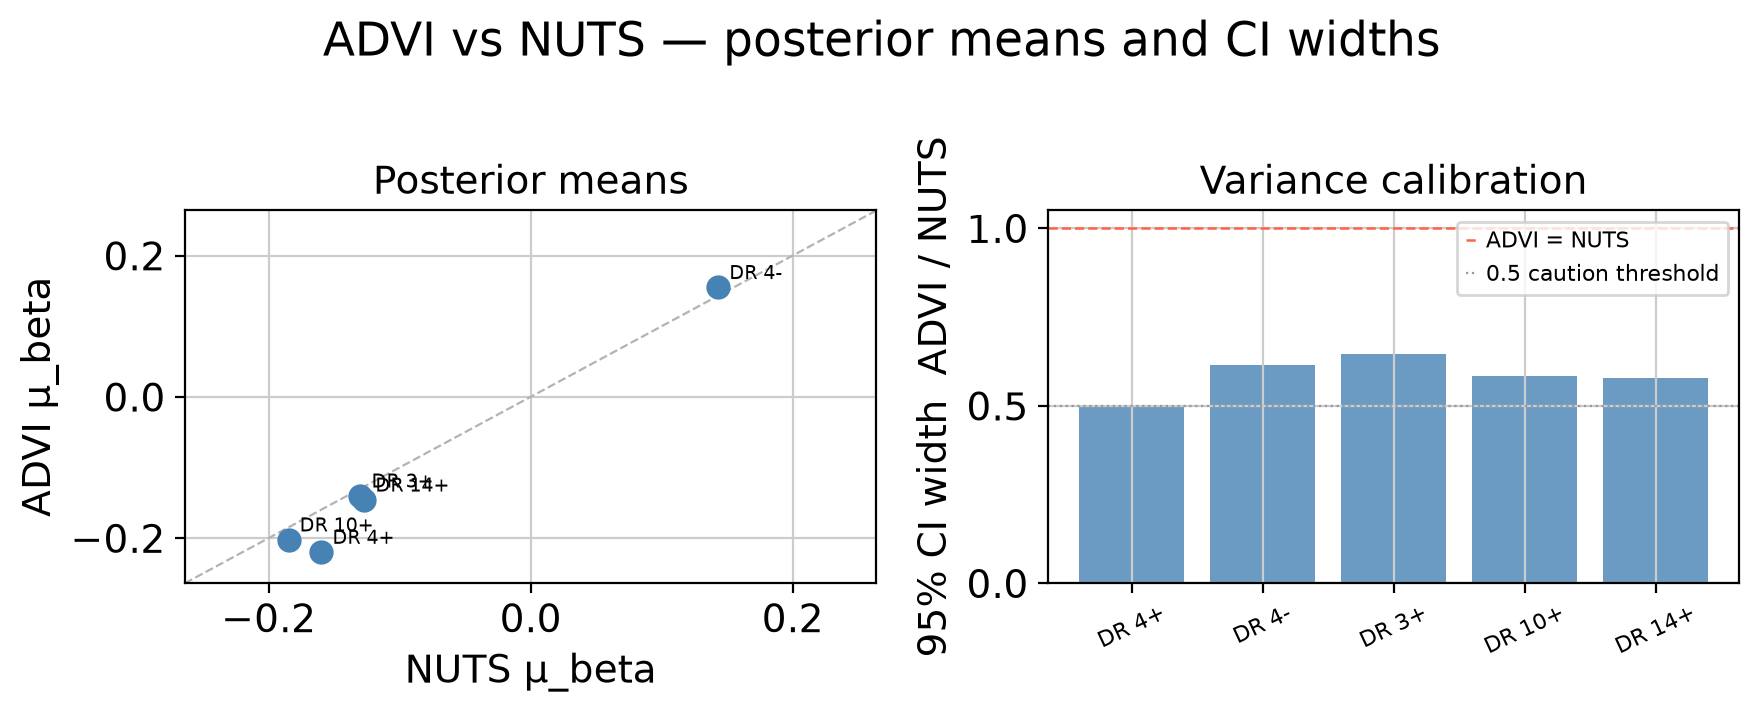

In [15]:
rows = []
for direction, trace in nuts_traces.items():
    nuts_post  = trace.posterior["mu_beta"].values.flatten()
    nuts_mean  = float(nuts_post.mean())
    nuts_width = float(np.percentile(nuts_post, 97.5) - np.percentile(nuts_post, 2.5))

    vi = vi_results["composite"].loc[direction]
    rows.append({
        "direction":       direction,
        "advi_mean":       vi["mu_beta_mean"],
        "nuts_mean":       nuts_mean,
        "mean_diff":       vi["mu_beta_mean"] - nuts_mean,
        "advi_ci_width":   vi["mu_beta_high"] - vi["mu_beta_low"],
        "nuts_ci_width":   nuts_width,
        "width_ratio":     (vi["mu_beta_high"] - vi["mu_beta_low"]) / nuts_width,
    })

cal = pd.DataFrame(rows).set_index("direction")
print("ADVI vs NUTS (top-5 directions):")
print(cal.round(3).to_string())
print(f"\nMean width ratio ADVI/NUTS: {cal['width_ratio'].mean():.2f}"
      " (< 1 = ADVI narrower = variance underestimated)")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

ax = axes[0]
lim = max(cal[["advi_mean", "nuts_mean"]].abs().to_numpy().max() * 1.2, 0.05)
ax.plot([-lim, lim], [-lim, lim], ls="--", color="0.7", lw=0.8)
ax.scatter(cal["nuts_mean"], cal["advi_mean"], s=60, color="steelblue", zorder=3)
for name, row in cal.iterrows():
    ax.annotate(name, (row["nuts_mean"], row["advi_mean"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.set(xlabel="NUTS μ_beta", ylabel="ADVI μ_beta",
       xlim=(-lim, lim), ylim=(-lim, lim), title="Posterior means")

ax = axes[1]
x = range(len(cal))
ax.bar(x, cal["width_ratio"], color="steelblue", alpha=0.8)
ax.axhline(1, color="tomato", ls="--", lw=0.9, label="ADVI = NUTS")
ax.axhline(0.5, color="0.6",  ls=":",  lw=0.8, label="0.5 caution threshold")
ax.set(xticks=x, xticklabels=cal.index, ylabel="95% CI width  ADVI / NUTS",
       title="Variance calibration")
ax.tick_params(axis="x", rotation=25, labelsize=8)
ax.legend(fontsize=8)

plt.suptitle("ADVI vs NUTS — posterior means and CI widths", y=1.02)
plt.tight_layout()
plt.show()

## 7 — Pathology specificity

`CPS_Local` is a composite of ABeta and pTau. The two components are correlated
but not interchangeable; a direction can favour one. The fits below compare the
slopes from the three phenotypes so that the *gap* between ABeta and pTau slopes
carries the specificity claim — neither column alone is sufficient.

Read the gap, not either slope: a direction driven by tau will still show a
substantial ABeta slope, because the two scores correlate.

In [16]:
# Compare posterior mean slopes across the three CPS phenotypes.
patho = pd.DataFrame({
    "composite_slope": vi_results["composite"]["mu_beta_mean"],
    "ABeta_slope":     vi_results["ABeta"]["mu_beta_mean"],
    "pTau_slope":      vi_results["pTau"]["mu_beta_mean"],
    "composite_p_pos": vi_results["composite"]["p_positive"],
    "ABeta_p_pos":     vi_results["ABeta"]["p_positive"],
    "pTau_p_pos":      vi_results["pTau"]["p_positive"],
})
patho["gap"] = patho["ABeta_slope"] - patho["pTau_slope"]
# "strong" = P(slope > 0) > 0.95 or P(slope < 0) > 0.95 on at least one component
P_CUT = 0.95
patho["any_strong"] = (
    (patho["composite_p_pos"] > P_CUT) | (patho["composite_p_pos"] < 1 - P_CUT) |
    (patho["ABeta_p_pos"]     > P_CUT) | (patho["ABeta_p_pos"]     < 1 - P_CUT) |
    (patho["pTau_p_pos"]      > P_CUT) | (patho["pTau_p_pos"]      < 1 - P_CUT)
)
strong = patho[patho["any_strong"]]
print(f"Directions with P(slope) > {P_CUT} or < {1-P_CUT} on ≥1 component: {len(strong)}")
print("Most component-specific (largest gap):")
strong.reindex(strong["gap"].abs().sort_values(ascending=False).index)[
    ["composite_slope", "ABeta_slope", "pTau_slope", "gap"]
].head(12).round(3)

Directions with P(slope) > 0.95 or < 0.050000000000000044 on ≥1 component: 86
Most component-specific (largest gap):


,composite_slope,ABeta_slope,pTau_slope,gap
direction,,,,
DR 18+,0.060,-0.050,0.140,-0.189
DR 7-,-0.029,-0.102,0.065,-0.167
DR 7+,-0.085,0.001,-0.145,0.146
DR 18-,-0.004,0.062,-0.083,0.144
DR 3+,-0.140,-0.059,-0.190,0.132
DR 28+,-0.136,-0.061,-0.192,0.131
DR 17+,-0.099,-0.028,-0.158,0.130
DR 17-,0.218,0.123,0.247,-0.124
DR 31+,-0.190,-0.115,-0.239,0.124


The two components are far from interchangeable, so a direction can plausibly
favour one. They are not independent either: a direction genuinely driven by
ABeta will still show a substantial pTau slope. Only the *gap* between the two
carries the specificity claim; read the difference, never either column alone.

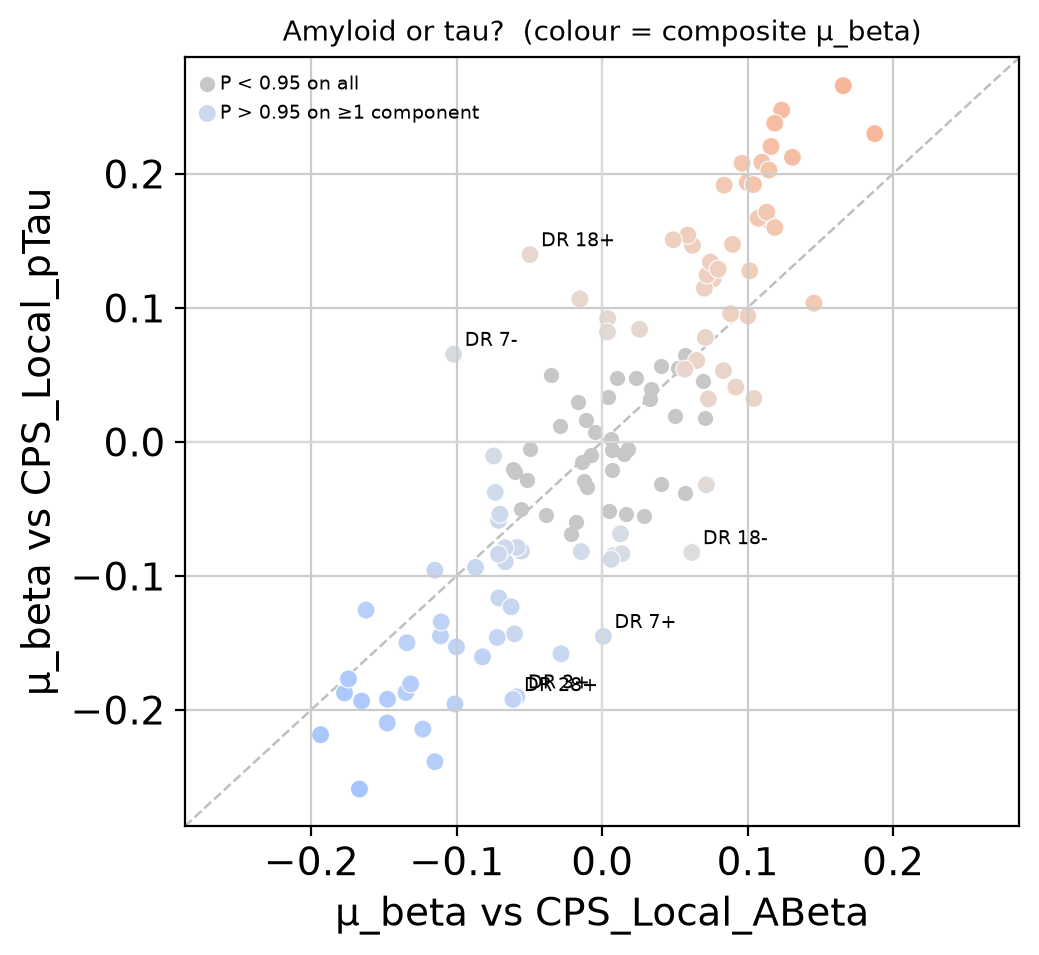

In [17]:
fig, ax = plt.subplots(figsize=(5.4, 5.0))
lim = 1.08 * patho[["ABeta_slope", "pTau_slope"]].abs().to_numpy().max()
ax.plot([-lim, lim], [-lim, lim], ls="--", color="0.75", lw=0.9, zorder=0)
ax.axhline(0, color="0.85", lw=0.8)
ax.axvline(0, color="0.85", lw=0.8)
hit = patho["any_strong"]
ax.scatter(patho.loc[~hit, "ABeta_slope"], patho.loc[~hit, "pTau_slope"],
           s=20, color="0.78", label=f"P < {P_CUT} on all")
ax.scatter(patho.loc[hit, "ABeta_slope"], patho.loc[hit, "pTau_slope"],
           s=42, c=patho.loc[hit, "composite_slope"], cmap="coolwarm",
           vmin=-0.7, vmax=0.7, edgecolor="white", linewidth=0.4,
           label=f"P > {P_CUT} on ≥1 component")
for name in patho.loc[hit, "gap"].abs().nlargest(6).index:
    ax.annotate(name, (patho.loc[name, "ABeta_slope"], patho.loc[name, "pTau_slope"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.set(xlim=(-lim, lim), ylim=(-lim, lim),
       xlabel="μ_beta vs CPS_Local_ABeta",
       ylabel="μ_beta vs CPS_Local_pTau")
ax.set_title("Amyloid or tau?  (colour = composite μ_beta)", fontsize=10)
ax.legend(fontsize=7, frameon=False, loc="upper left")
plt.tight_layout()

In [18]:
leans_ptau = patho["pTau_slope"].abs() > patho["ABeta_slope"].abs()
signed_rank = stats.wilcoxon(patho["pTau_slope"].abs(), patho["ABeta_slope"].abs())
print(f"|μ_beta| larger for pTau in {int(leans_ptau.sum())} of {len(patho)} directions "
      f"(Wilcoxon signed-rank p = {signed_rank.pvalue:.1e})")
for label in ["composite", "ABeta", "pTau"]:
    print(f"  median |μ_beta|  {label}: {patho[f'{label}_slope'].abs().median():.3f}")

|μ_beta| larger for pTau in 92 of 124 directions (Wilcoxon signed-rank p = 2.5e-10)
  median |μ_beta|  composite: 0.079
  median |μ_beta|  ABeta: 0.068
  median |μ_beta|  pTau: 0.086


The lean is cohort-wide, not a property of a few directions: most live directions
have a larger slope against tau than against amyloid, and the signed-rank test on
the paired magnitudes is not close. The honest reading is therefore about the
latent space as a whole — **these factors track tau burden more closely than
amyloid burden** — rather than about any single direction being tau-specific.

Two alternative explanations are printed above: a score with more spread across
units lifts every association with it, and the composite is itself nearer one
component, so a direction fit to track "progression" inherits some of that bias.

## 8 — Compositional context

`/data/multiregion/pertpy/CPS_Local/` holds a finished scCODA compositional
analysis of all 174 supertypes against `CPS_Local`. The cells below read it and
ask whether the directions that track CPS mark the supertypes scCODA says are
depleted. See the analysis README for the four caveats about how to use it.

In [19]:
# SUPERTYPES from the within pseudobulk written by 03_pseudobulk.
within_meta = pd.read_parquet(PSEUDO_DIR / "within_meta.parquet")
SUPERTYPES = within_meta.index.get_level_values("Supertype").unique().tolist()
print(f"{len(SUPERTYPES)} SST supertypes")

# Three values with three meanings, which a naive fillna(0) would collapse:
# NaN  -- supertype absent from that region, never modelled
# 0.0  -- modelled, but scCODA did not call the effect credible
# else -- a credible shift (negative = depleted)
summary_path = sorted(S.CPS_LOCAL_DIR.glob(S.SCCODA_SUMMARY_GLOB))[-1]
summary = pd.read_csv(summary_path, index_col=0)
effects = (summary[summary["Cell Type"].isin(SUPERTYPES)]
           .pivot(index="Cell Type", columns="Region", values="Local Model"))
effects.columns.name = None
print(f"{summary_path.name}: {effects.shape[0]} supertypes x {effects.shape[1]} regions -- "
      f"{int((effects.fillna(0) != 0).to_numpy().sum())} credible, "
      f"{int((effects == 0).to_numpy().sum())} not credible, "
      f"{int(effects.isna().to_numpy().sum())} not modelled")
effects.round(2)

19 SST supertypes


pertpy_summary_CPS_Local.20260313.csv: 19 supertypes x 10 regions -- 84 credible, 72 not credible, 34 not modelled


,AnG,DFC,FI,HIP,ITG,LEC,MEC,MTG,STG,V1C
Cell Type,,,,,,,,,,
Sst_1,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00
Sst_10,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Sst_11,-0.88,-0.88,-0.88,NaN,-0.88,-0.88,-0.88,-1.57,-0.88,NaN
Sst_12,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Sst_13,-0.42,-0.42,-0.42,-0.42,-0.42,-0.42,-0.42,-0.42,-0.42,-0.42
Sst_19,-0.74,-0.74,-0.74,NaN,-0.74,-0.74,-0.74,-1.39,-0.74,-0.74
Sst_2,-0.83,-0.83,-0.83,NaN,-0.83,-0.83,-0.83,-1.74,-0.83,-0.83
Sst_20,-0.96,-0.96,-0.96,NaN,-0.96,-0.96,-0.96,-1.90,-0.96,-0.96
Sst_22,-0.45,-0.45,-0.45,-0.45,-0.45,-0.45,-0.45,-0.45,-0.45,NaN


### That table has ten columns and does not have ten measurements

The shape invites a supertype × region heatmap. Before drawing one: independent
per-region MCMC fits cannot agree to six decimal places, and across the SST
supertypes this table's effect is a single value repeated over every region the
supertype appears in — MTG being the one exception. Reading it as ten regional
measurements would multiply the evidence by ten.

In [20]:
rows = {}
for supertype, values in effects.iterrows():
    present = values.dropna()
    if present.empty:
        continue
    mode = present.mode()
    shared = float(mode.iloc[0]) if len(mode) else np.nan
    rows[supertype] = {
        "n_regions": len(present),
        "n_distinct": int(present.nunique()),
        "shared_effect": shared,
        "deviating_regions": ", ".join(present.index[present != shared]) or "-",
    }
specificity = pd.DataFrame(rows).T.astype(
    {"n_regions": int, "n_distinct": int, "shared_effect": float})
specificity.index.name = "Cell Type"
print(f"{int((specificity['n_distinct'] == 1).sum())} of {len(specificity)} supertypes "
      "carry one value across every region they appear in")
specificity

11 of 19 supertypes carry one value across every region they appear in


,n_regions,n_distinct,shared_effect,deviating_regions
Cell Type,,,,
Sst_1,9,1,0.000000,-
Sst_10,10,1,0.000000,-
Sst_11,8,2,-0.878724,MTG
Sst_12,10,1,0.000000,-
Sst_13,10,1,-0.424789,-
Sst_19,9,2,-0.742641,MTG
Sst_2,9,2,-0.828178,MTG
Sst_20,9,2,-0.961262,MTG
Sst_22,9,1,-0.450876,-


So the usable scCODA quantity for the SST cohort is **one CPS_Local abundance
effect per supertype** (`shared_effect`), not a regional map. Significance is the
posterior inclusion probability, not a non-zero `Final Parameter`.

In [21]:
# Reads the reference-sweep to get inclusion probabilities and effect spread.
# The neuronal results files are ~180 MB total; this chunk-read is the fast path.
SWEEP_COLUMNS = ["Region", "Covariate", "Cell Type", "Final Parameter",
                 "Inclusion probability", "Reference Cell Type"]
chunks = []
for path in sorted(S.CPS_LOCAL_DIR.glob(S.SCCODA_RESULTS_GLOB)):
    for chunk in pd.read_csv(path, usecols=SWEEP_COLUMNS, chunksize=500_000):
        chunk = chunk[(chunk["Covariate"] == "CPS_Local")
                      & chunk["Cell Type"].isin(SUPERTYPES)]
        if len(chunk):
            chunks.append(chunk)
swept = pd.concat(chunks, ignore_index=True)
swept = swept[swept["Cell Type"] != swept["Reference Cell Type"]]
by_cr = swept.groupby(["Cell Type", "Region"], observed=True)
sweep = pd.DataFrame({
    "n_references": by_cr["Final Parameter"].size(),
    "median_effect": by_cr["Final Parameter"].median(),
    "effect_p05": by_cr["Final Parameter"].quantile(0.05),
    "effect_p95": by_cr["Final Parameter"].quantile(0.95),
    "median_inclusion": by_cr["Inclusion probability"].median(),
    "frac_credible": by_cr["Inclusion probability"].apply(
        lambda v: float((v >= S.SCCODA_INCLUSION_THRESHOLD).mean())),
})
global_fit = sweep.xs("Global", level="Region").sort_values("median_effect")
print(f"{len(sweep)} supertype x region cells from "
      f"{int(sweep['n_references'].median())} references each")

209 supertype x region cells from 173 references each


### The summary *is* the region-agnostic fit

The boundary for credibility runs between `Sst_9` (inclusion 0.815, zeroed) and
`Sst_22` (0.841, kept). The summary reproduces the sweep's Global estimate to
within 0.016 for every called effect.

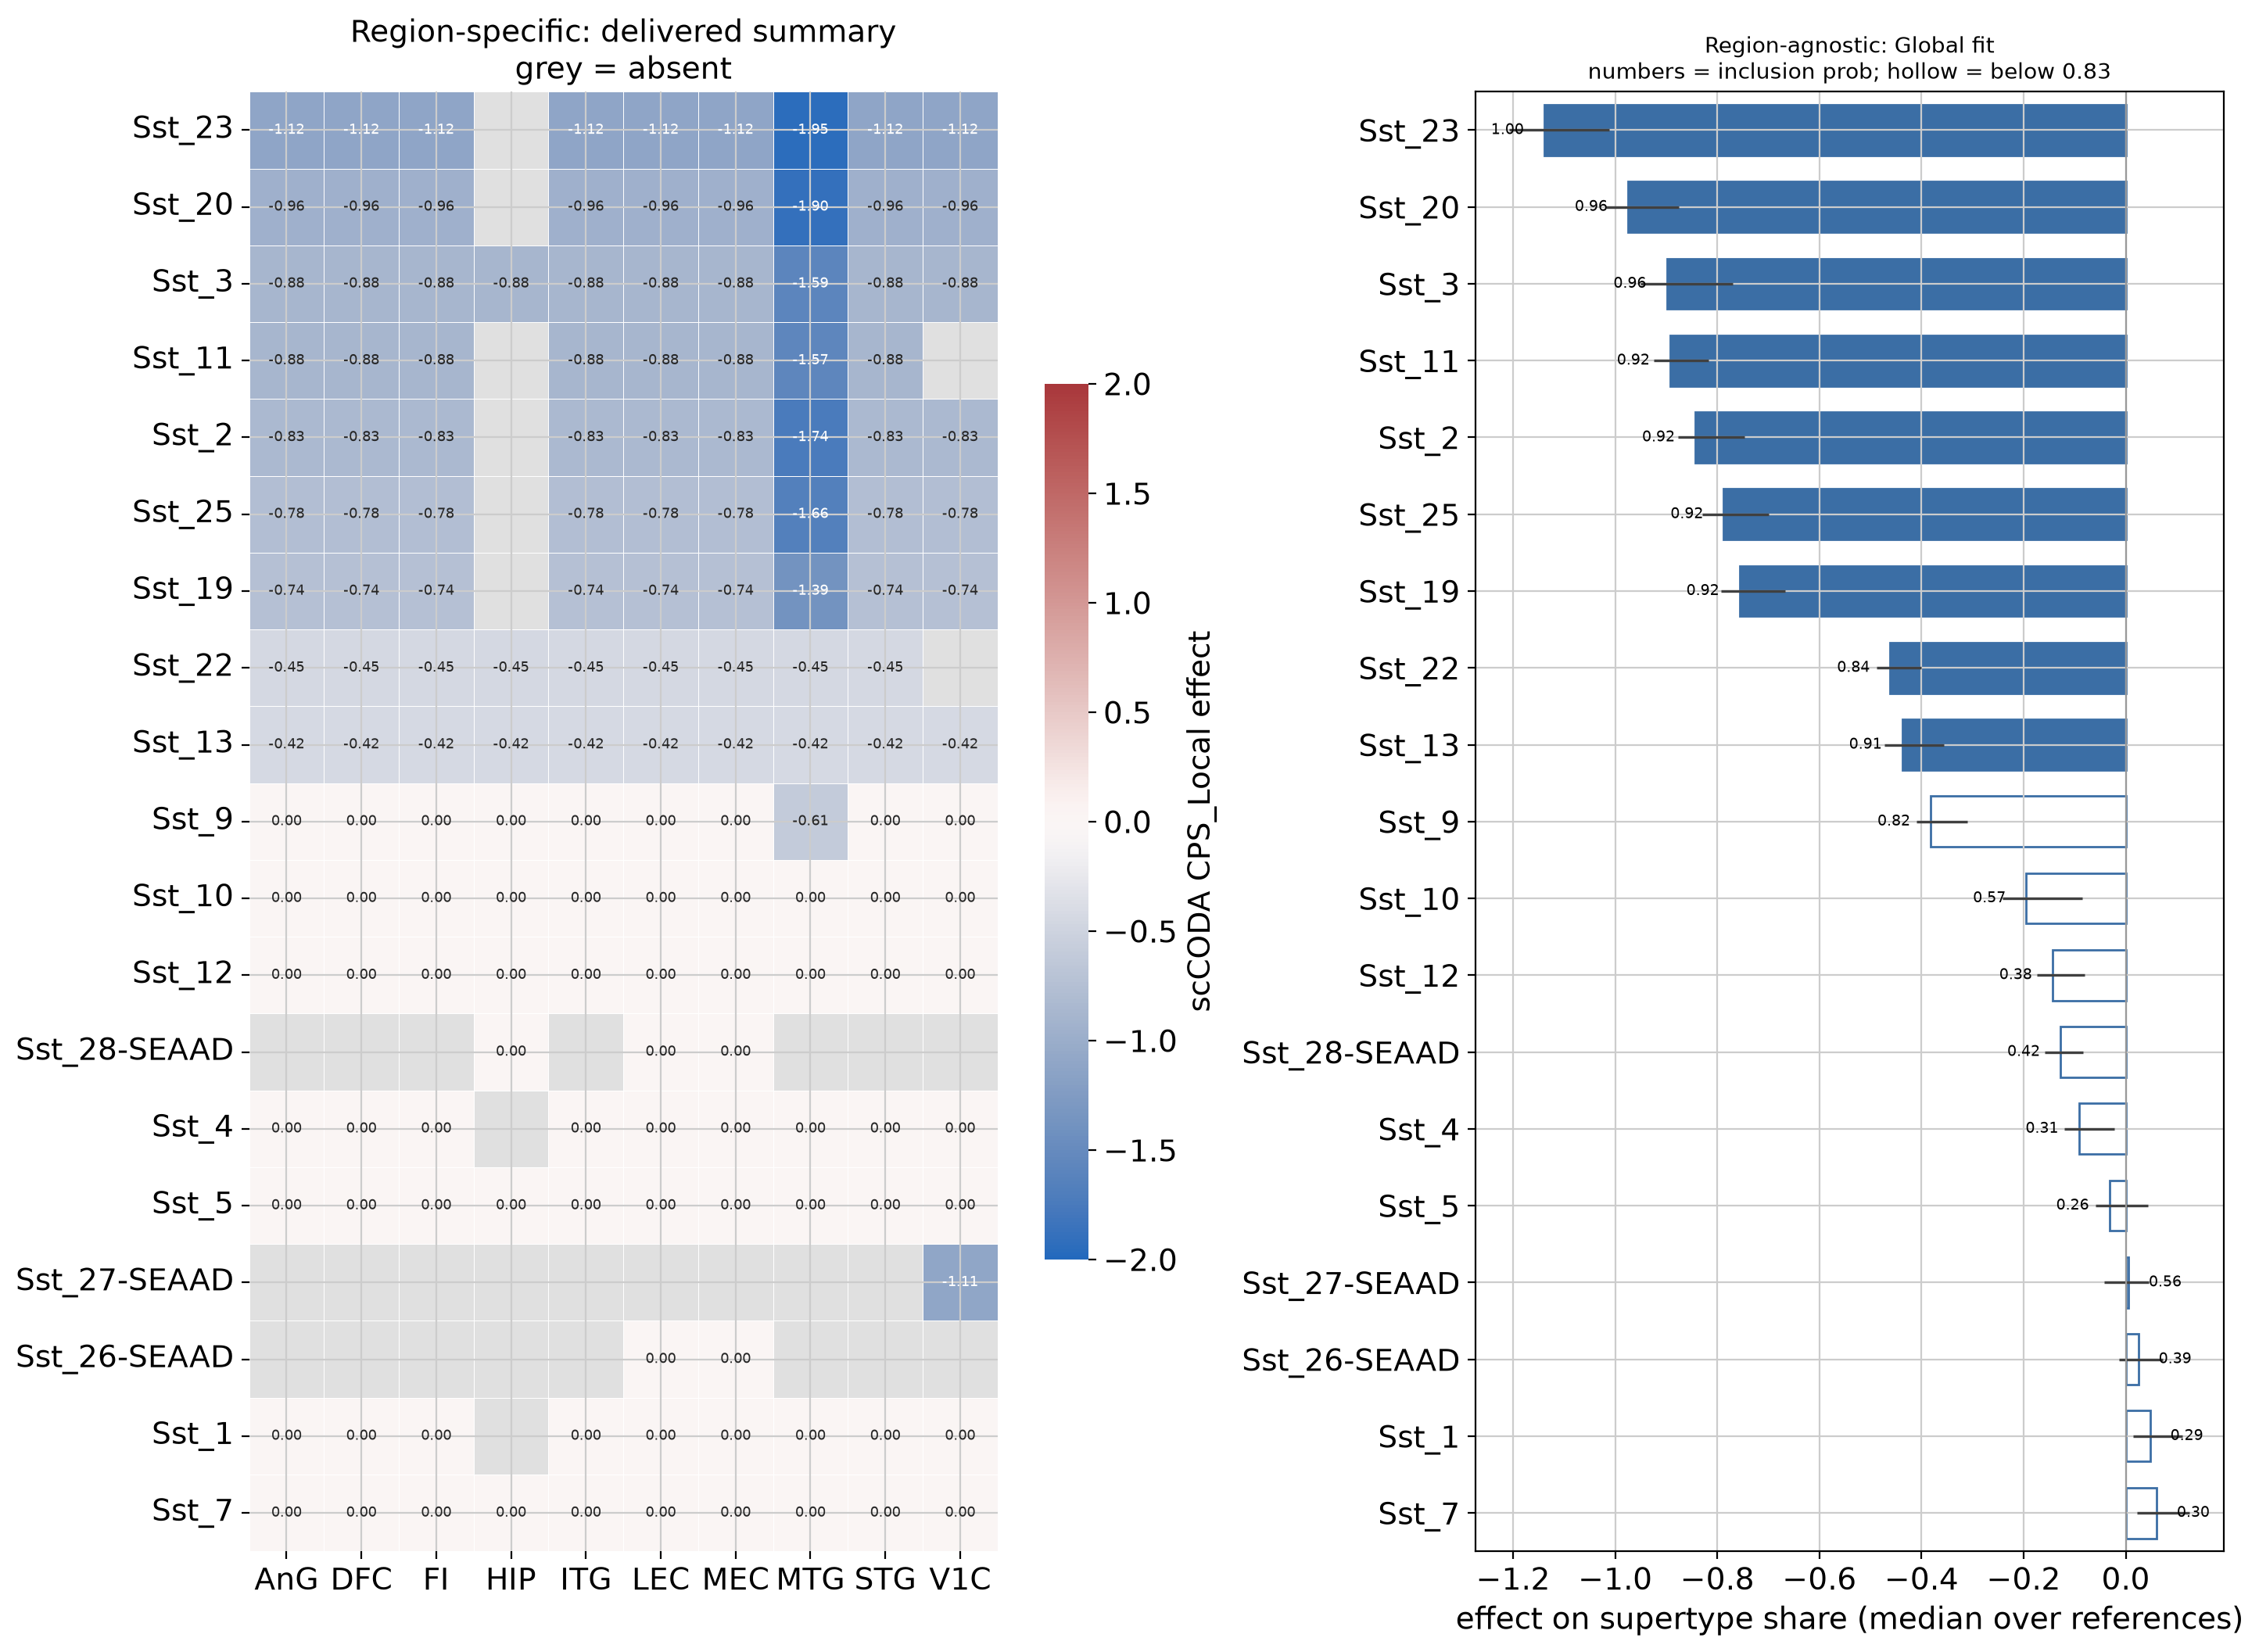

In [22]:
order = global_fit.index
fig, axes = plt.subplots(1, 2, figsize=(14.5, 0.42 * len(order) + 2.8),
                         gridspec_kw={"width_ratios": [1.25, 1]})
axes[0].set_facecolor("0.88")
sns.heatmap(effects.reindex(order), cmap="vlag", center=0, vmin=-2, vmax=2,
            annot=True, fmt=".2f", annot_kws={"fontsize": 6.5}, linewidths=0.3,
            cbar_kws={"label": "scCODA CPS_Local effect", "shrink": 0.6}, ax=axes[0])
axes[0].set(title="Region-specific: delivered summary\ngrey = absent", xlabel="", ylabel="")
credible = (global_fit["median_inclusion"] >= S.SCCODA_INCLUSION_THRESHOLD).to_numpy()
y = np.arange(len(order))
axes[1].barh(y, global_fit["median_effect"], height=0.66,
             color=np.where(credible, "#3b6ea5", "white"), edgecolor="#3b6ea5")
axes[1].hlines(y, global_fit["effect_p05"], global_fit["effect_p95"], color="0.25", lw=1.2)
for pos, (_, row) in enumerate(global_fit.iterrows()):
    left = row["median_effect"] < 0
    axes[1].text(row["median_effect"] + (-0.04 if left else 0.04), pos,
                 f"{row['median_inclusion']:.2f}", fontsize=7, va="center",
                 ha="right" if left else "left")
axes[1].axvline(0, color="0.6", lw=0.8)
axes[1].set(yticks=y, yticklabels=order, ylim=(len(order) - 0.5, -0.5),
            xlabel="effect on supertype share (median over references)")
axes[1].set_title(f"Region-agnostic: Global fit\n"
                  f"numbers = inclusion prob; hollow = below {S.SCCODA_INCLUSION_THRESHOLD}", fontsize=10)
plt.tight_layout()

### 8b — Direction link

Do the directions that track CPS also mark the depleted supertypes? Each direction
gets an x-coordinate from how strongly its per-supertype activation profile
correlates (Spearman) with the scCODA depletion effect, and a y-coordinate from
its CPS association slope.

In [23]:
# Posterior mean slopes for each direction (composite phenotype).
composite_df = vi_results["composite"]

# Supertype profile from within pseudobulk.
within_act = pd.read_parquet(PSEUDO_DIR / "within_activity.parquet")
profile = within_act.groupby(level="Supertype").mean()
profile = (profile - profile.mean()) / profile.std(ddof=0).mask(lambda s: s == 0)

vulnerability = specificity["shared_effect"].reindex(profile.index)
usable = vulnerability.notna()

link = pd.DataFrame({
    "profile_vs_vulnerability": profile[usable.to_numpy()].corrwith(
        vulnerability[usable], method="spearman"
    ),
    "mu_beta_mean": composite_df["mu_beta_mean"],
    "p_positive":   composite_df["p_positive"],
}).dropna()
link["composition_marker"] = link["profile_vs_vulnerability"].abs() > 0.5
link.reindex(link["mu_beta_mean"].abs().sort_values(ascending=False).index).head(15).round(3)

,profile_vs_vulnerability,mu_beta_mean,p_positive,composition_marker
DR 15+,-0.484,-0.246,0.0,False
DR 36+,0.549,0.245,1.0,True
DR 53-,0.236,0.241,1.0,False
DR 16+,-0.369,-0.237,0.0,False
DR 4+,-0.729,-0.220,0.0,True
DR 17-,0.521,0.218,1.0,True
DR 35-,-0.456,-0.216,0.0,False
DR 21+,-0.545,-0.215,0.0,True
DR 47+,0.451,0.211,1.0,False
DR 44+,-0.234,-0.205,0.0,False


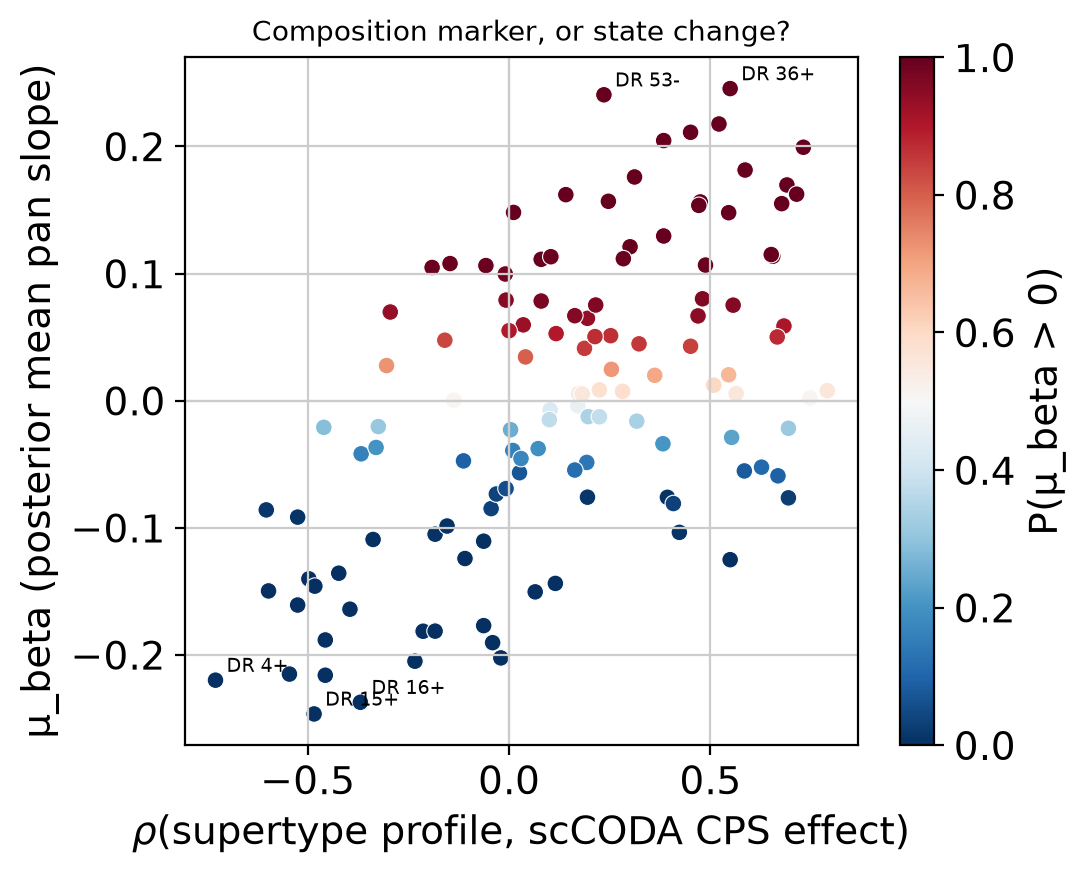

In [24]:
# x: does the direction mark depleted supertypes?
# y: how strongly does it track CPS (posterior mean slope)?
# colour: posterior probability of positive association.
fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.axhline(0, color="0.8", lw=0.8)
ax.axvline(0, color="0.8", lw=0.8)
points = ax.scatter(
    link["profile_vs_vulnerability"], link["mu_beta_mean"],
    c=link["p_positive"], cmap="RdBu_r", vmin=0, vmax=1,
    s=36, edgecolor="white", linewidth=0.4,
)
for name in link["mu_beta_mean"].abs().nlargest(5).index:
    ax.annotate(name,
                (link.loc[name, "profile_vs_vulnerability"], link.loc[name, "mu_beta_mean"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
fig.colorbar(points, ax=ax, label="P(μ_beta > 0)")
ax.set(xlabel=r"$\rho$(supertype profile, scCODA CPS effect)",
       ylabel="μ_beta (posterior mean pan slope)")
ax.set_title("Composition marker, or state change?", fontsize=10)
plt.tight_layout()

In [25]:
from session_info2 import session_info
session_info(dependencies=True)

Package,Version
pandas,3.0.5
arviz,1.3.0
matplotlib,3.11.1
numpy,2.4.6
pymc,6.3.1
pytensor,3.3.0
scanpy,1.12.4
seaborn,0.13.2
scipy,1.18.1
graphviz,0.21
